## Sprint 4 - Modelado y evaluacion estadistica

### Preparacion para el analisis estadistico

In [2]:
# Importar librerias necesarias
# para analisis inicial y manipulacion de datos
import pandas as pd
import numpy as np

# para visualización grafica de los datos
import matplotlib.pyplot as plt
import seaborn as sns

# para manejo mas complejo de datos
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Cargar los datos
df_universidad = pd.read_csv('../datos_limpios/Datos_universidad.csv')

In [ ]:
# Primero preparamos las variables numericas
# ==============================================================================

# Crea un diccionario llamado 'map_tiempo'. Las llaves son los textos originales del CSV y los valores son el punto medio matematico de ese rango temporal.
map_tiempo = {
    '0-30 min': 15,
    '30-60 min': 45,
    '61-90 min': 75,
    '91-120 min': 105,
    'Mas de 120 min': 135
}
#La función 'map()' busca en la columna 'tiempo_llegada' los valores del diccionario y los reemplaza por sus valores numericos. 
#El resultado se guarda en una nueva columna llamada 'minutos_llegada' y 'minutos_regreso'.
df_universidad['minutos_llegada'] = df_universidad['tiempo_llegada'].map(map_tiempo)
df_universidad['minutos_regreso'] = df_universidad['tiempo_regreso'].map(map_tiempo)

# Calcular horas de viaje semanales: (ida + vuelta) * dias de asistencia / 60
df_universidad['horas_viaje_semanal'] = ((df_universidad['minutos_llegada'] + df_universidad['minutos_regreso']) * df_universidad['dias_asistencia']) / 60

# Mapeo de promedios academicos usando la marca de clase del rango
map_promedio = {'3.0 a 3.5': 3.25, '3.6 a 4.0': 3.8, '4.1 a 4.5': 4.3, '4.6 a 5': 4.8}
#Aplica el diccionario a la columna 'promedio_academico' creando una nueva columna con valores numericos continuos llamada 'promedio_num'.
df_universidad['promedio_num'] = df_universidad['promedio_academico'].map(map_promedio)

In [9]:
# 1. VALIDACIÓN DE HIPOTESIS
# ==============================================================================
print("="*60)
print("--- RESULTADOS: VALIDACION DE HIPOTESIS ---")
print("="*60)

# H1: Tiempos en horas pico vs valle
# se filtra las filas donde 'hora_desplazamiento' contiene la palabra 'valle', 'pico' (ignorando mayusculas 'case=False' y nulos 'na=False'), selecciona la columna 'minutos_llegada' de ese filtro y calcula su media (mean).
valle = df_universidad[df_universidad['hora_desplazamiento'].str.contains('valle', case=False, na=False)]['minutos_llegada'].mean()
pico = df_universidad[df_universidad['hora_desplazamiento'].str.contains('pico', case=False, na=False)]['minutos_llegada'].mean()
print(f"H1: Tiempo medio en hora pico: {pico:.1f} min | Hora valle: {valle:.1f} min")

# H2: 2 a 3 llegadas tardias por semana
# se hace el calculo directamente el promedio (mean) de toda la columna 'llegadas_tarde'
promedio_tardes = df_universidad['llegadas_tarde'].mean()
print(f"H2: El estudiante promedio llega tarde {promedio_tardes:.1f} veces a la semana.")

# H3: 50% registra inasistencia o llegada tarde
# Se filtra el DataFrame para quedarse solo con aquellos estudiantes que llegaron tarde mas de 0 veces (llegadas_tarde > 0) O (|) que perdieron mas de 0 clases 
afectados_asistencia = df_universidad[(df_universidad['llegadas_tarde'] > 0) | (df_universidad['pierde_clase'] > 0)]
# se calcula el porcentaje dividiendo el número de filas filtradas ('len(afectados_asistencia)') entre el numero total de filas ('len(df_universidad)') y lo multiplica por 100
porcentaje_afectados = (len(afectados_asistencia) / len(df_universidad)) * 100
print(f"H3: El {porcentaje_afectados:.1f}% de los estudiantes registra al menos 1 llegada tarde o inasistencia.")

# H4: Transporte publico 50-90 min
# Se define una lista con los nombres exactos que representan al transporte publico en la base de datos
transporte_publico = ['bus', 'transmilenio (buses troncales, sitp, alimentador)']
# Se filtra el DataFrame reteniendo solo las filas donde la columna 'medio_transporte' este dentro (.isin) de la lista 'transporte_publico', luego selecciona 'minutos_llegada' y le saca el promedio
tiempo_tp = df_universidad[df_universidad['medio_transporte'].isin(transporte_publico)]['minutos_llegada'].mean()
print(f"H4: El tiempo promedio en transporte publico es {tiempo_tp:.1f} minutos.")

# H5: 8 a 12 horas semanales en movilidad
# Calcula el promedio general de la columna 'horas_viaje_semanal'.
horas_semana_promedio = df_universidad['horas_viaje_semanal'].mean()
print(f"H5: Un estudiante invierte en promedio {horas_semana_promedio:.1f} horas semanales en movilidad.")

# H6: Mayor inasistencia en horas pico
# Se filtra a los que viajan en hora 'pico', 'valle'y calcula el promedio de clases perdidas ('pierde_clase')
inasistencia_pico = df_universidad[df_universidad['hora_desplazamiento'].str.contains('pico', case=False, na=False)]['pierde_clase'].mean()
inasistencia_valle = df_universidad[df_universidad['hora_desplazamiento'].str.contains('valle', case=False, na=False)]['pierde_clase'].mean()
print(f"H6: Inasistencia en hora pico: {inasistencia_pico:.2f} clases/semana | Hora valle: {inasistencia_valle:.2f} clases/semana")

# H7: Trayectos > 60 min (inasistencia 15-20% superior)
# se calcula el promedio de clases perdidas para toda la poblacion
inasist_general = df_universidad['pierde_clase'].mean()
# se filtra a los estudiantes cuyos minutos de llegada sean superiores a 60 y se calcula su promedio de clases perdidas.
inasist_largos = df_universidad[df_universidad['minutos_llegada'] > 60]['pierde_clase'].mean()
if inasist_general > 0:
    # si hay inasistencias generales, se calcula la diferencia porcentual entre los que viajan mucho y el promedio general y se imprime
    incremento = ((inasist_largos - inasist_general) / inasist_general) * 100
    print(f"H7: Estudiantes >60min faltan {inasist_largos:.2f} veces (incremento del {incremento:.1f}% vs promedio general de {inasist_general:.2f})")
else:
    print("H7: No hay inasistencias en general para comparar.")

# H8: Menor promedio a mas inasistencias
# se filtra a los que nunca faltan (pierde_clase == 0) y calcula el promedio de sus notas ('promedio_num')
promedio_0_faltas = df_universidad[df_universidad['pierde_clase'] == 0]['promedio_num'].mean()
# se filtra a los que faltan 1 o mas veces (pierde_clase >= 1) y se calcula el promedio de sus notas ('promedio_num')
promedio_mas_faltas = df_universidad[df_universidad['pierde_clase'] >= 1]['promedio_num'].mean()
print(f"H8: Notas de quienes NO faltan: {promedio_0_faltas:.2f} | Notas de quienes faltan 1+ veces: {promedio_mas_faltas:.2f}")

--- RESULTADOS: VALIDACION DE HIPOTESIS ---
H1: Tiempo medio en hora pico: 60.0 min | Hora valle: 19.3 min
H2: El estudiante promedio llega tarde 1.6 veces a la semana.
H3: El 74.0% de los estudiantes registra al menos 1 llegada tarde o inasistencia.
H4: El tiempo promedio en transporte publico es 56.0 minutos.
H5: Un estudiante invierte en promedio 6.3 horas semanales en movilidad.
H6: Inasistencia en hora pico: 1.00 clases/semana | Hora valle: 0.14 clases/semana
H7: Estudiantes >60min faltan 1.23 veces (incremento del 105.1% vs promedio general de 0.60)
H8: Notas de quienes NO faltan: 4.18 | Notas de quienes faltan 1+ veces: 3.96


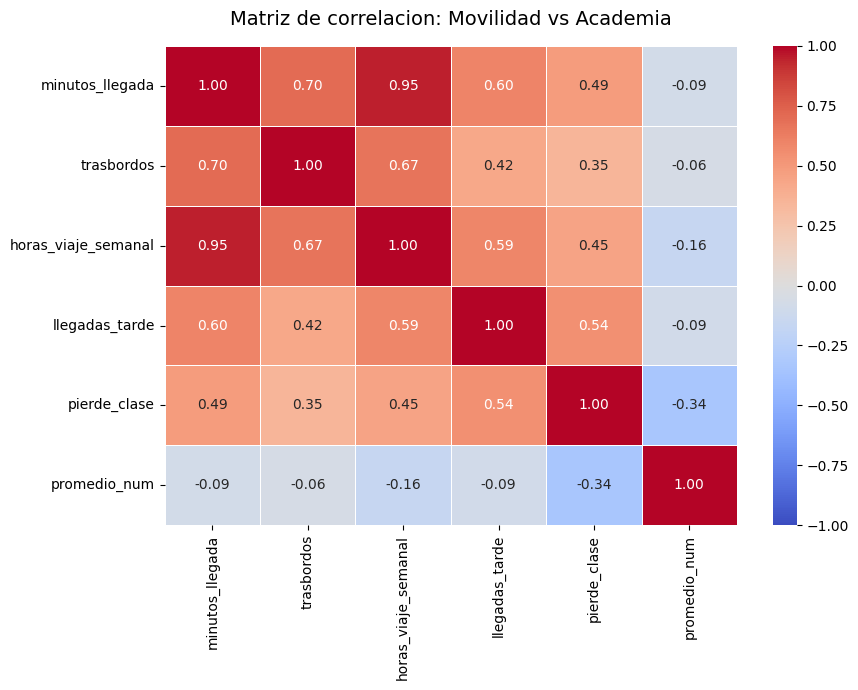

In [10]:
# 2. ANALISIS CORRELACIONAL
# se define la lista explicita con los nombres de las columnas numericas que se desean correlacionar
columnas_corr = ['minutos_llegada', 'trasbordos', 'horas_viaje_semanal', 'llegadas_tarde', 'pierde_clase', 'promedio_num']
df_corr = df_universidad[columnas_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de correlacion: Movilidad vs Academia", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [12]:
# 3. MODELO PREDICTIVO (RANDOM FOREST)
print("--- MODELO PREDICTIVO (RIESGO DE BAJO RENDIMIENTO) ---")

# Define nuestra "Variable Objetivo" teniendo la condición que si el promedio numerico es menor o igual a 3.8 O (|) pierde clases
# Si es Verdadero, asigna 1 (tiene Riesgo). Si es Falso, asigna 0 (no tiene Riesgo) y se crea la columna 'riesgo_academico'
df_universidad['riesgo_academico'] = np.where((df_universidad['promedio_num'] <= 3.8) | (df_universidad['pierde_clase'] > 0), 1, 0)

# Definimos la lista con las variables independientes que el algoritmo usara para predecir el riesgo
features = ['minutos_llegada', 'trasbordos', 'horas_viaje_semanal', 'dias_asistencia']

# Limpiamos posibles valores nulos generados en la conversión
X = df_universidad[features].fillna(0)
y = df_universidad['riesgo_academico']

# Se divide los datos de prueba
# 'test_size=0.3' significa que el 30% de los datos será para probar y el 70% para entrenar
# 'random_state=42' fija una "semilla" para que esta separacion aleatoria sea siempre la misma y los resultados sean reproducibles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Ejecuta el aprendizaje algorítmico del modelo pasando las variables independientes (X) y las respuestas correctas (y) del conjunto de entrenamiento. 
# y el modelo encuentra los patrones matematicos
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)

print("\n>> Reporte de clasificacion del modelo predictivo:")
# Usamos la funcion 'classification_report', comparando las respuestas reales (y_test) 
# con las que predijo el modelo (y_pred) e imprime las metricas de precision, exhaustividad (recall) y F1-Score en pantalla
print(classification_report(y_test, y_pred))

# inicia un ciclo que itera los nombres de las variables y su peso de importancia extraído arriba.
importancias = clf.feature_importances_
print("\n>> Nivel de impacto logistico sobre el riesgo academico:")
for feature, imp in zip(features, importancias):
    # en cada paso del ciclo, imprime el nombre de la variable y su importancia multiplicada por 100 para verla en formato porcentaje con un decimal
    print(f" - {feature}: {imp*100:.1f}%")

--- MODELO PREDICTIVO (RIESGO DE BAJO RENDIMIENTO) ---

>> Reporte de clasificacion del modelo predictivo:
              precision    recall  f1-score   support

           0       0.25      0.17      0.20         6
           1       0.55      0.67      0.60         9

    accuracy                           0.47        15
   macro avg       0.40      0.42      0.40        15
weighted avg       0.43      0.47      0.44        15


>> Nivel de impacto logistico sobre el riesgo academico:
 - minutos_llegada: 12.2%
 - trasbordos: 18.0%
 - horas_viaje_semanal: 53.8%
 - dias_asistencia: 16.0%
